# **DOWNLOAD DATASET FROM INGV VIA API PER BATCH**

In [4]:
import requests
import pandas as pd
from io import StringIO
import time
import os

url = "https://webservices.ingv.it/fdsnws/event/1/query"
base_params = {
    "minmag": 1.5,
    "minlat": 34,  
    "maxlat": 48,  
    "minlon": 3,   
    "maxlon": 22,  
    "format": "text"
}

# monthly intervals from 1985 to 2025
time_bins = pd.date_range(start='1985-01-01', end='2026-01-01', freq='MS')

all_earthquakes = []
total_batches = len(time_bins) - 1

print(f"Starting batch download ({total_batches} monthly batches)...")
print("This will take a few minutes. Please don't interrupt the process.")

for i in range(total_batches):
    start_time = time_bins[i].strftime("%Y-%m-%dT00:00:00")
    # Subtract 1 second from the next month's start to get the end of the current month
    end_time = (time_bins[i+1] - pd.Timedelta(seconds=1)).strftime("%Y-%m-%dT23:59:59")
    
    current_params = base_params.copy()
    current_params["starttime"] = start_time
    current_params["endtime"] = end_time
    
    # Make request
    response = requests.get(url, params=current_params)
    
    # Handle response
    if response.status_code == 200:
        # Data found: read and append to list
        data_io = StringIO(response.text)
        df_batch = pd.read_csv(data_io, sep='|')
        all_earthquakes.append(df_batch)
    
    elif response.status_code == 204:
        # 204 No Content: perfectly normal if no earthquakes >= 1.5 occurred that month
        pass
        
    else:
        # Log any other errors but keep trying next batches
        print(f"\nError in batch {start_time} to {end_time}: HTTP {response.status_code}")
    
    # Print progress every 24 months
    if (i + 1) % 24 == 0 or (i + 1) == total_batches:
        print(f"Progress: {i + 1}/{total_batches} batches processed...")
        
    time.sleep(0.3)

# Merge DataFrames
print("\nMerging all batches into a single DataFrame...")
df_raw = pd.concat(all_earthquakes, ignore_index=True)

# Standardize column names
df_raw.columns = [col.lower() for col in df_raw.columns]
df_raw = df_raw.rename(columns={"depth/km": "depth_km"})
df_filtered = df_raw.query("eventtype == 'earthquake'")
df_filtered = df_filtered.filter(items=["time", "latitude", "longitude", "depth_km", "magnitude"])

filename = "data/INGV/italy_earthquakes_1985_2025.csv"
df_filtered.to_csv(filename, index=False)
file_path = os.path.abspath(filename)
print(f"Success! {len(df_filtered)} total earthquakes retrieved and merged.")
print(f"Complete dataset saved to: {file_path}")

display(df_filtered.head())

Starting batch download (492 monthly batches)...
This will take a few minutes. Please don't interrupt the process.
Progress: 24/492 batches processed...
Progress: 48/492 batches processed...
Progress: 72/492 batches processed...
Progress: 96/492 batches processed...
Progress: 120/492 batches processed...
Progress: 144/492 batches processed...
Progress: 168/492 batches processed...
Progress: 192/492 batches processed...
Progress: 216/492 batches processed...
Progress: 240/492 batches processed...
Progress: 264/492 batches processed...
Progress: 288/492 batches processed...
Progress: 312/492 batches processed...
Progress: 336/492 batches processed...
Progress: 360/492 batches processed...
Progress: 384/492 batches processed...
Progress: 408/492 batches processed...
Progress: 432/492 batches processed...
Progress: 456/492 batches processed...
Progress: 480/492 batches processed...
Progress: 492/492 batches processed...

Merging all batches into a single DataFrame...
Success! 215679 total 

,time,latitude,longitude,depth_km,magnitude
0,1985-01-31T13:57:02.820000,38.721,21.556,10.0,3.8
1,1985-01-28T08:45:53.200000,42.515,13.313,10.0,2.5
2,1985-01-27T03:24:43.880000,40.759,15.250,10.0,2.9
3,1985-01-25T23:33:12.210000,39.135,16.000,99.7,3.1
4,1985-01-25T22:26:11.110000,40.571,19.310,10.0,2.8


# Original DB columns parameters:

- **EventID** ID assigned by the data center, as to be used with eventid parameter
- **Time** Origin time of the event in UTC
- **Latitude** Event latitude in degrees
- **Longitude** Event longitude in degrees
- **Depth/km** Event depth in kilometers
- **Author** Identifier of event origin author
- **Catalog** Identifier of source catalog
- **Contributor** Identifier of event information contributor
- **ContributorID** Event ID as reported by the contributor
- **MagType** Magnitude scale identifier (e.g. mb, ML, Mw)
- **Magnitude** Magnitude value
- **MagAuthor** Identifier of magnitude author
- **EventLocationName** Geographic description of event location (e.g. Flinn-Engdahl region name)
- **EventType** Event type classification string as of QuakeML 1.2 EventType enumeration

# ***Check of filtered DB***

In [5]:
print(f"The uploaded dataframe has {len(df_filtered):_} rows and {len(df_filtered.columns):_} columns.")
memory = df_filtered.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")
print(df_filtered.columns)
display( pd.concat([df_filtered.head(5),df_filtered.tail(5)]) )

The uploaded dataframe has 215_679 rows and 5 columns.
It occupies 23.65 MB in RAM memory
Index(['time', 'latitude', 'longitude', 'depth_km', 'magnitude'], dtype='str')


,time,latitude,longitude,depth_km,magnitude
0,1985-01-31T13:57:02.820000,38.7210,21.5560,10.0,3.8
1,1985-01-28T08:45:53.200000,42.5150,13.3130,10.0,2.5
2,1985-01-27T03:24:43.880000,40.7590,15.2500,10.0,2.9
3,1985-01-25T23:33:12.210000,39.1350,16.0000,99.7,3.1
4,1985-01-25T22:26:11.110000,40.5710,19.3100,10.0,2.8
216480,2025-12-01T10:35:34.450000,45.8927,11.9652,7.8,1.5
216481,2025-12-01T07:12:13.000000,42.7787,12.7258,10.4,1.9
216482,2025-12-01T03:10:19.730000,45.8738,7.0510,11.1,1.6
216483,2025-12-01T02:25:48.990000,44.1677,9.9072,6.4,1.7
216484,2025-12-01T01:27:50.160000,44.5130,10.2288,25.0,2.4


Loading the filtered Italian dataset...
Dataset ready: 215679 earthquakes loaded.


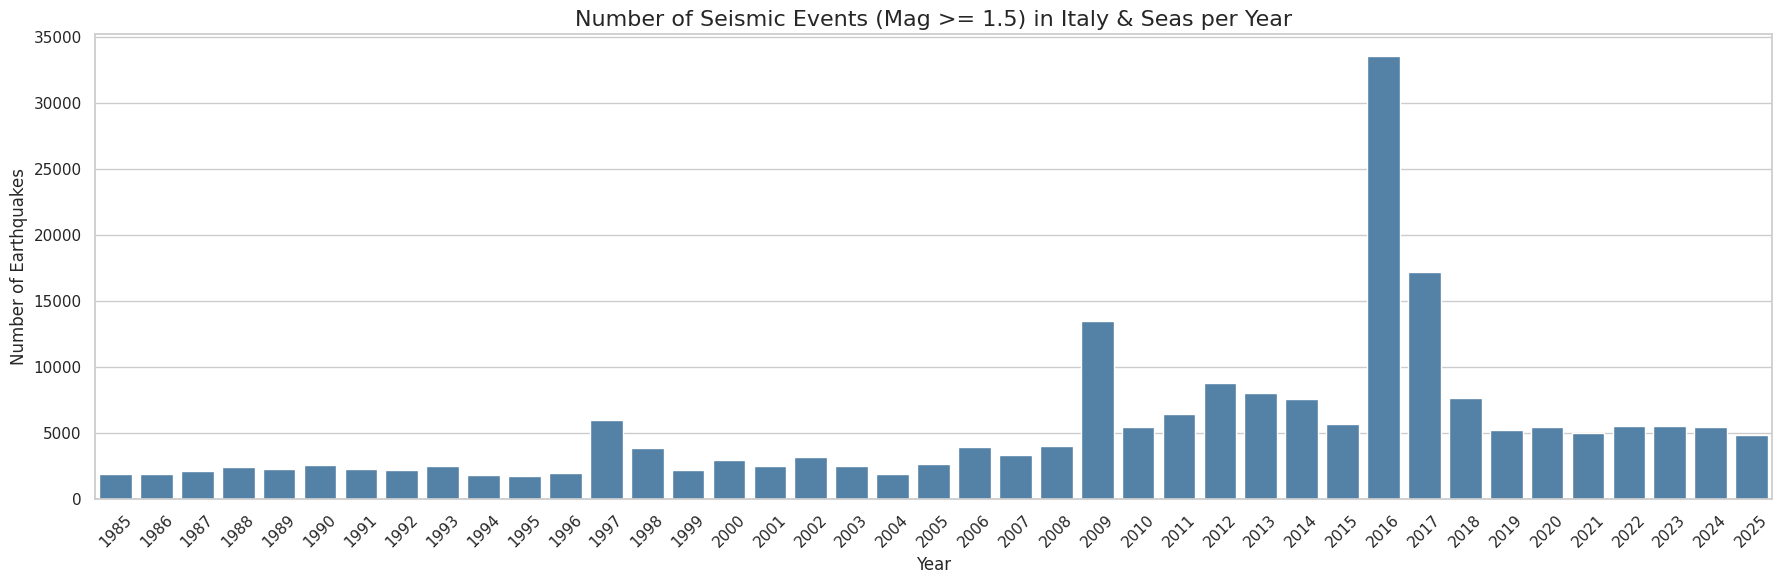

/tmp/ipykernel_1110656/979121268.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')


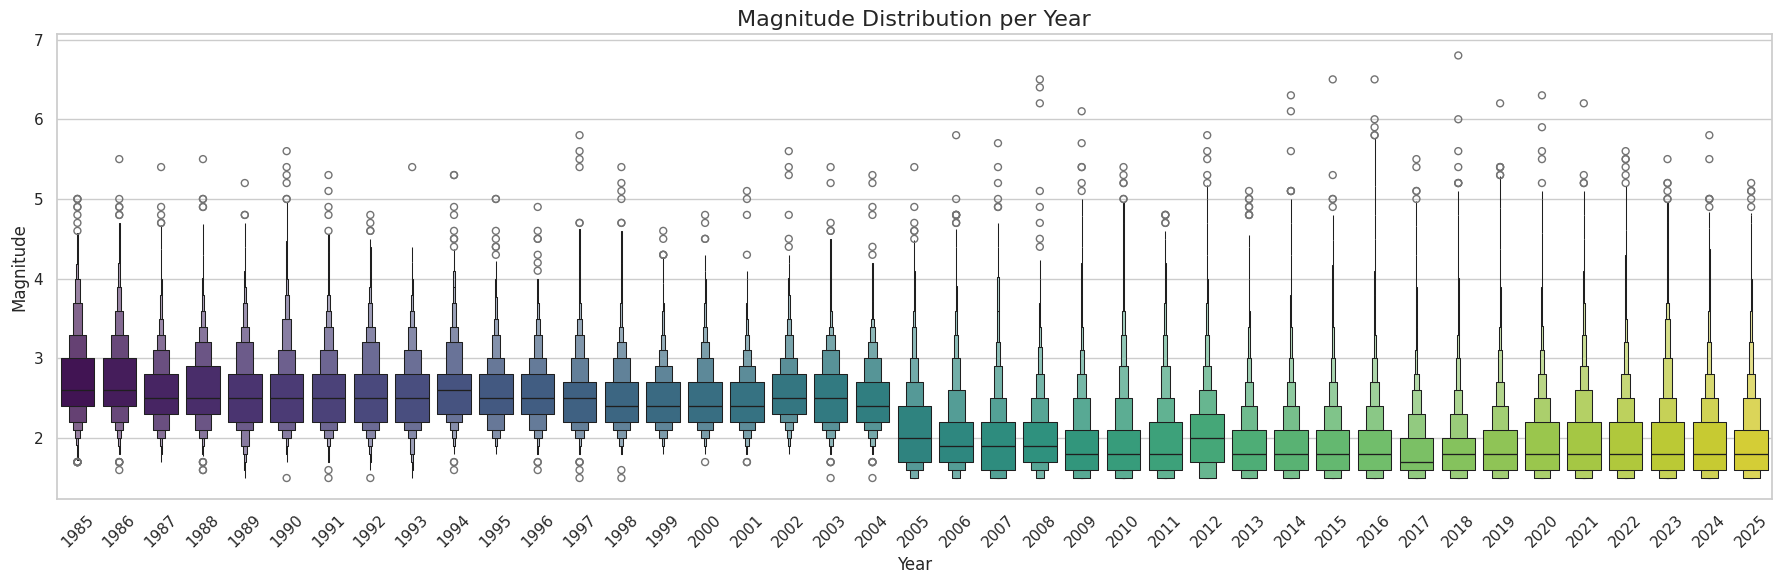

/tmp/ipykernel_1110656/979121268.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='depth_km', palette='magma')


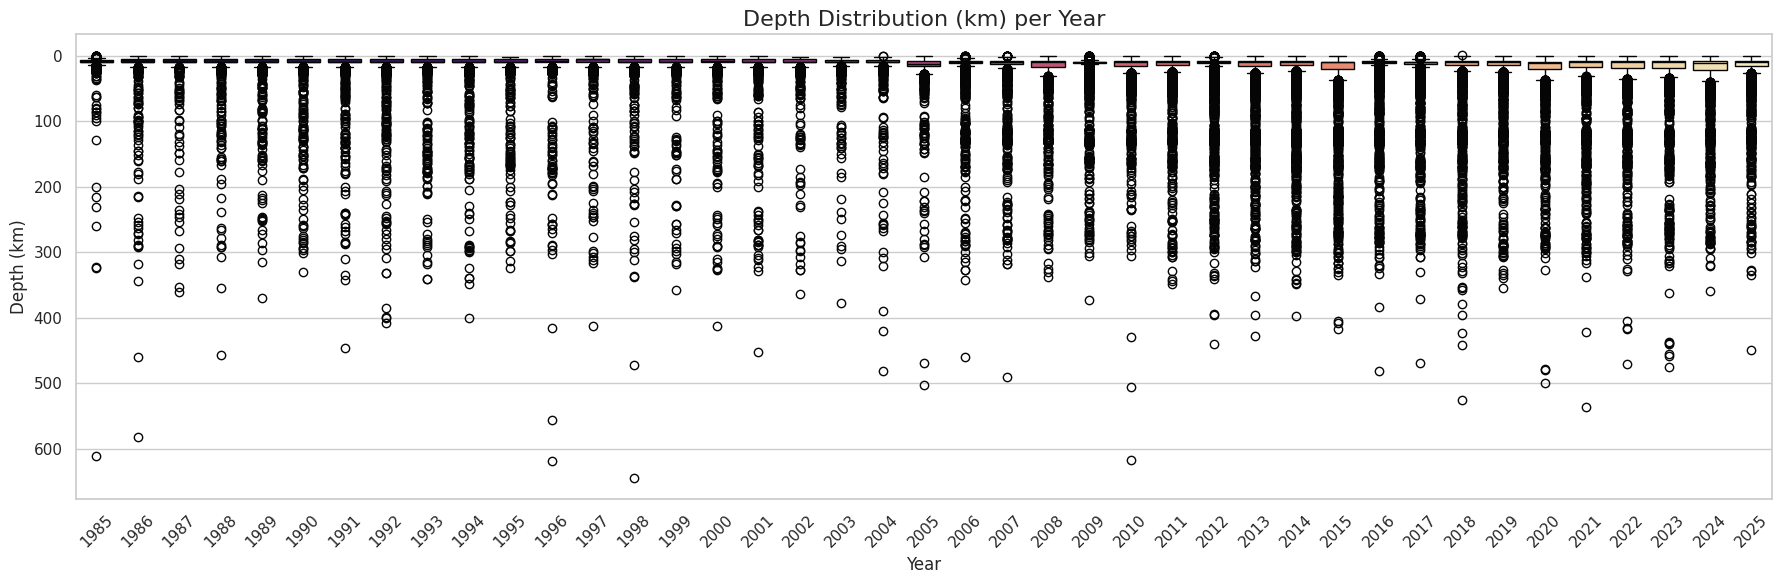

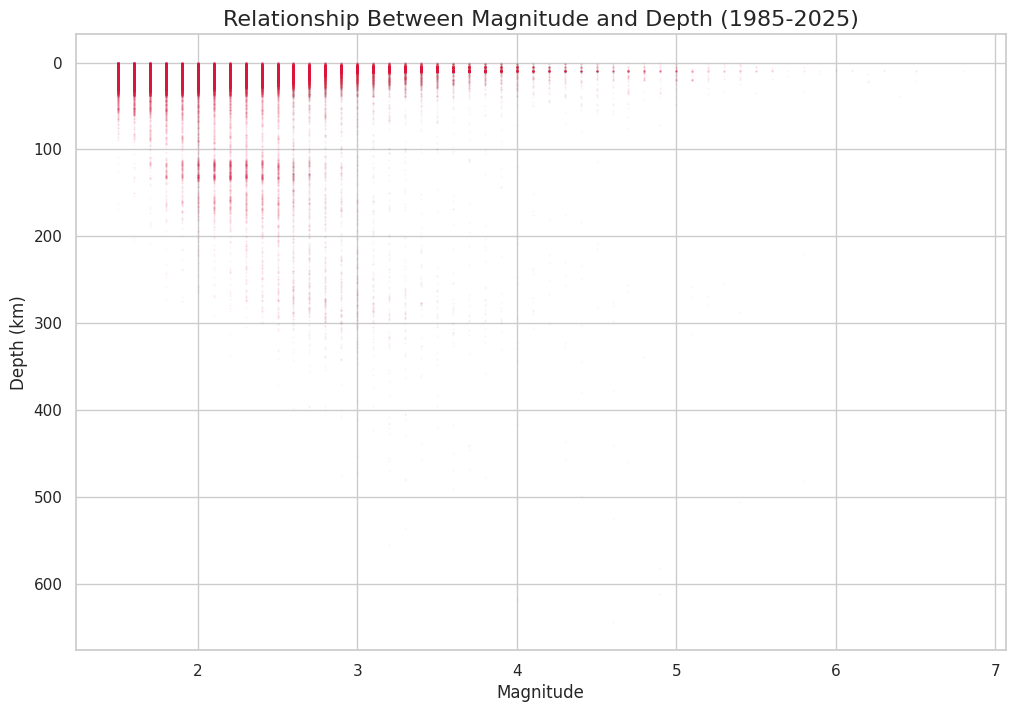

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

print("Loading the filtered Italian dataset...")
df = pd.read_csv("data/INGV/italy_earthquakes_1985_2025.csv")

df['time'] = pd.to_datetime(df['time'], utc=True)
df['year'] = df['time'].dt.year

print(f"Dataset ready: {len(df)} earthquakes loaded.")

# Earthquake Frequency Over Time
plt.figure(figsize=(18, 6))
year_counts = df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of Seismic Events (Mag >= 1.5) in Italy & Seas per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.tight_layout()
plt.show()

# Magnitude Distribution per Year
plt.figure(figsize=(18, 6))
sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')
plt.xticks(rotation=45)
plt.title('Magnitude Distribution per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

# Depth Distribution per Year
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x='year', y='depth_km', palette='magma')
plt.gca().invert_yaxis() 
plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

# Relationship Between Depth and Magnitude
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='magnitude', y='depth_km', alpha=0.05, s=2, color='crimson')
plt.gca().invert_yaxis()
plt.title('Relationship Between Magnitude and Depth (1985-2025)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

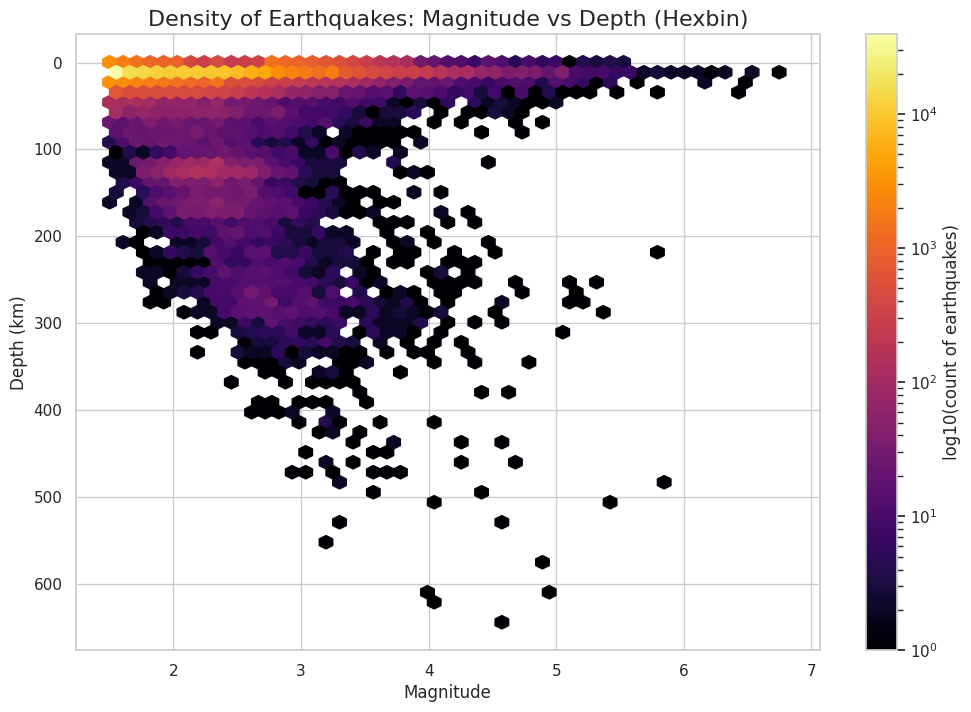

In [12]:
plt.figure(figsize=(12, 8))
hb = plt.hexbin(df['magnitude'], df['depth_km'], gridsize=50, cmap='inferno', mincnt=1, bins='log')
plt.colorbar(hb, label='log10(count of earthquakes)')
plt.gca().invert_yaxis()
plt.title('Density of Earthquakes: Magnitude vs Depth (Hexbin)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

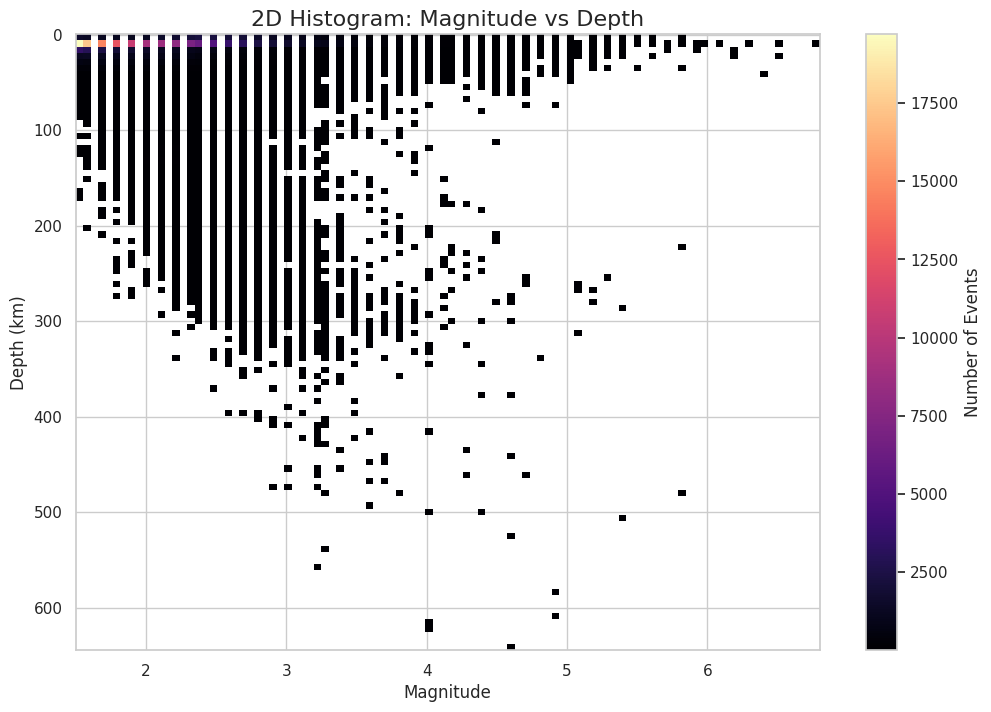

In [13]:
plot_df = df[['magnitude', 'depth_km']].dropna()
plt.figure(figsize=(12, 8))
plt.hist2d(plot_df['magnitude'], plot_df['depth_km'], bins=100, cmap='magma', cmin=1)
plt.colorbar(label='Number of Events')
plt.gca().invert_yaxis()
plt.title('2D Histogram: Magnitude vs Depth', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

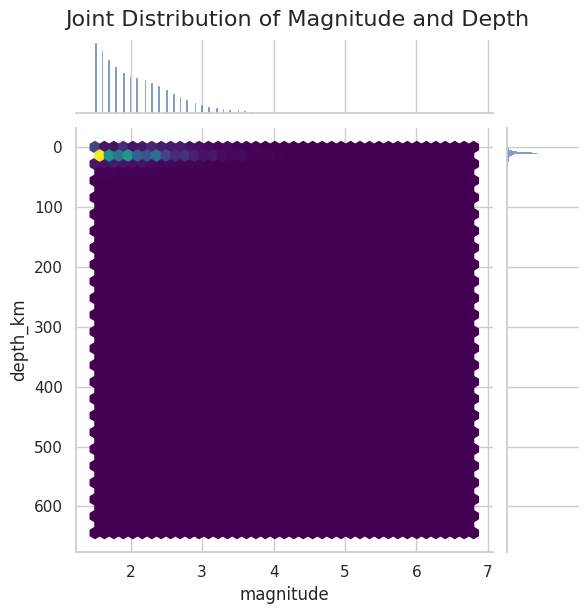

In [14]:
g = sns.jointplot(data=df, x='magnitude', y='depth_km', kind='hex', cmap='viridis', gridsize=40)
g.ax_joint.invert_yaxis()
g.fig.suptitle('Joint Distribution of Magnitude and Depth', y=1.02, fontsize=16)
plt.show()

/tmp/ipykernel_1110656/702833299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mag_bin', y='depth_km', palette='coolwarm', showfliers=False)


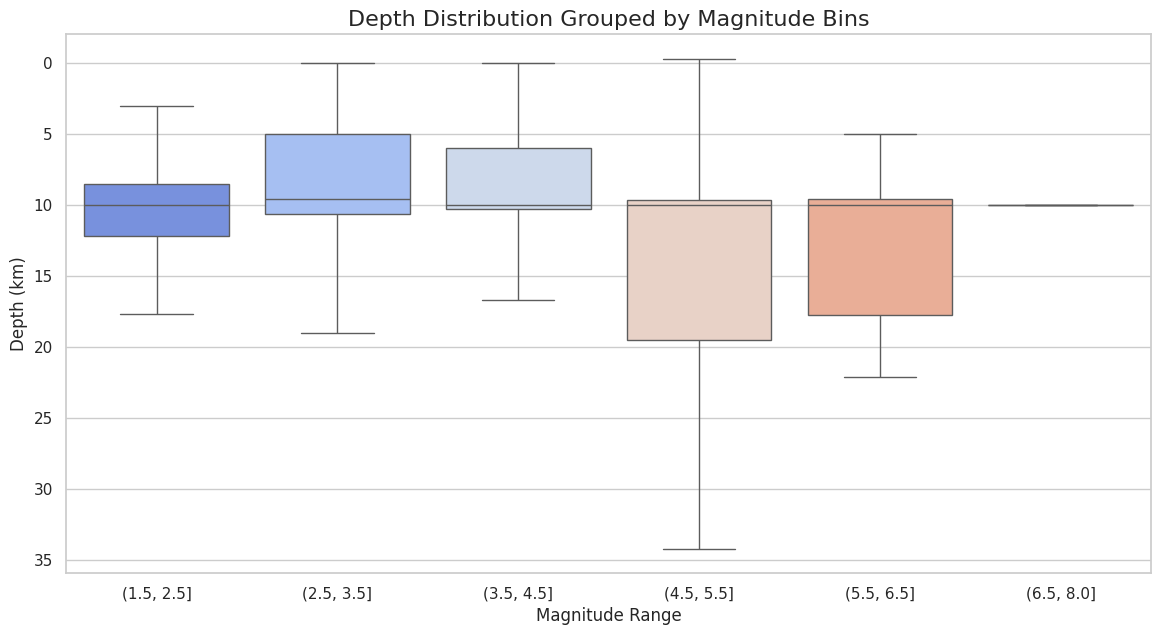

In [15]:
plt.figure(figsize=(14, 7))
df['mag_bin'] = pd.cut(df['magnitude'], bins=[1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 8.0])
sns.boxplot(data=df, x='mag_bin', y='depth_km', palette='coolwarm', showfliers=False)
plt.gca().invert_yaxis()
plt.title('Depth Distribution Grouped by Magnitude Bins', fontsize=16)
plt.xlabel('Magnitude Range')
plt.ylabel('Depth (km)')
plt.show()